### Load Dataset and Initial Exploration

In [76]:
import pandas as pd

df = pd.read_excel('/content/Gamer_Churn_Prediction_Dataset.xlsx')

display(df.head())

,Player_ID,Player_Level,Average_Session_Length_Mins,Login_Frequency_Last_14_Days,Days_Since_Last_Login,In_App_Purchases_USD,Failed_Level_Attempts,Support_Tickets_Raised,Target_Will_Churn_Next_7_Days
0,100000,52,37.1,13,18,22.69,20,1,0
1,100001,87,85.4,11,21,6.09,39,2,1
2,100002,53,131.3,2,20,41.84,1,3,1
3,100003,33,112.0,12,26,0.11,24,0,1
4,100004,59,13.2,10,11,54.60,14,2,0


In [77]:
df.shape

(4500, 9)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Player_ID                      4500 non-null   int64  
 1   Player_Level                   4500 non-null   int64  
 2   Average_Session_Length_Mins    4500 non-null   float64
 3   Login_Frequency_Last_14_Days   4500 non-null   int64  
 4   Days_Since_Last_Login          4500 non-null   int64  
 5   In_App_Purchases_USD           4500 non-null   float64
 6   Failed_Level_Attempts          4500 non-null   int64  
 7   Support_Tickets_Raised         4500 non-null   int64  
 8   Target_Will_Churn_Next_7_Days  4500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 316.5 KB


In [79]:
display(df.describe())

,Player_ID,Player_Level,Average_Session_Length_Mins,Login_Frequency_Last_14_Days,Days_Since_Last_Login,In_App_Purchases_USD,Failed_Level_Attempts,Support_Tickets_Raised,Target_Will_Churn_Next_7_Days
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.00000,4500.000000,4500.000000
mean,102249.500000,50.194889,92.418556,7.554444,14.866222,15.081144,24.65800,1.991556,0.454889
std,1299.182435,28.250004,50.663088,4.027237,8.613989,15.240795,14.42711,1.405043,0.498016
min,100000.000000,1.000000,5.100000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,101124.750000,26.000000,48.200000,4.000000,7.000000,4.360000,12.00000,1.000000,0.000000
50%,102249.500000,50.000000,92.400000,8.000000,15.000000,10.550000,24.00000,2.000000,0.000000
75%,103374.250000,75.000000,136.500000,11.000000,22.000000,20.552500,37.00000,3.000000,1.000000
max,104499.000000,99.000000,179.900000,14.000000,29.000000,128.150000,49.00000,4.000000,1.000000


In [80]:
df.columns

Index(['Player_ID', 'Player_Level', 'Average_Session_Length_Mins',
       'Login_Frequency_Last_14_Days', 'Days_Since_Last_Login',
       'In_App_Purchases_USD', 'Failed_Level_Attempts',
       'Support_Tickets_Raised', 'Target_Will_Churn_Next_7_Days'],
      dtype='object')

In [81]:
display(df.isnull().sum())

,0
Player_ID,0
Player_Level,0
Average_Session_Length_Mins,0
Login_Frequency_Last_14_Days,0
Days_Since_Last_Login,0
In_App_Purchases_USD,0
Failed_Level_Attempts,0
Support_Tickets_Raised,0
Target_Will_Churn_Next_7_Days,0


### Feature Preprocessing

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

df_processed = df.drop('Player_ID', axis=1)

X_features = df_processed.drop('Target_Will_Churn_Next_7_Days', axis=1)
y = df_processed['Target_Will_Churn_Next_7_Days']

numerical_cols = X_features.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X_features[numerical_cols], y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=numerical_cols, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=numerical_cols, index=X_test.index)

X_scaled_df = pd.DataFrame(scaler.fit_transform(X_features[numerical_cols]), columns=numerical_cols, index=X_features.index)

print("Data split and scaled correctly. X_train and X_test now contain scaled features based on training data fit.")
display(X_train.head())
display(X_test.head())
display(X_scaled_df.head())

Data split and scaled correctly. X_train and X_test now contain scaled features based on training data fit.


,Player_Level,Average_Session_Length_Mins,Login_Frequency_Last_14_Days,Days_Since_Last_Login,In_App_Purchases_USD,Failed_Level_Attempts,Support_Tickets_Raised
26,-0.210743,1.536309,0.099753,0.474429,-0.597046,0.446999,-1.409555
319,0.715688,-1.406686,-0.396942,0.008732,0.398294,0.516628,1.428475
2630,-0.068215,0.171184,0.348100,0.008732,-0.182593,0.238112,-0.700047
644,1.713382,-1.357439,1.341489,1.172976,-0.930566,0.725514,-1.409555
3532,0.501896,0.179064,1.093142,0.125156,0.355870,-0.597436,0.009460


,Player_Level,Average_Session_Length_Mins,Login_Frequency_Last_14_Days,Days_Since_Last_Login,In_App_Purchases_USD,Failed_Level_Attempts,Support_Tickets_Raised
1526,1.357063,1.081267,0.348100,0.940127,-0.890100,-0.667065,0.009460
2468,0.715688,-1.331831,-0.893636,0.707278,-0.553969,1.352175,0.009460
4454,1.570855,1.142333,0.099753,0.125156,0.555591,1.561062,0.718967
3815,0.680056,1.719507,0.099753,1.172976,1.247434,0.377370,1.428475
2147,-0.994646,1.087177,-0.148594,-0.107693,-0.806557,1.212917,0.718967


,Player_Level,Average_Session_Length_Mins,Login_Frequency_Last_14_Days,Days_Since_Last_Login,In_App_Purchases_USD,Failed_Level_Attempts,Support_Tickets_Raised
0,0.063905,-1.092012,1.352332,0.363841,0.499298,-0.322900,-0.705790
1,1.302980,-0.138549,0.855658,0.712151,-0.590005,0.994211,0.006011
2,0.099307,0.767536,-1.379373,0.596048,1.755934,-1.640012,0.717812
3,-0.608736,0.386546,1.103995,1.292666,-0.982416,-0.045614,-1.417592
4,0.311720,-1.563808,0.607321,-0.448880,2.593254,-0.738830,0.006011


In [83]:
print(f"Shape of features (X_scaled_df): {X_scaled_df.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of features (X_scaled_df): (4500, 7)
Shape of target (y): (4500,)


### Split Data into Training and Testing Sets

In [84]:
print("Data splitting is now handled in the preprocessing cell for correct order.")

Data splitting is now handled in the preprocessing cell for correct order.


### Check Class Imbalance

Churn Distribution in Training Set:
Target_Will_Churn_Next_7_Days
0    0.545
1    0.455
Name: proportion, dtype: float64


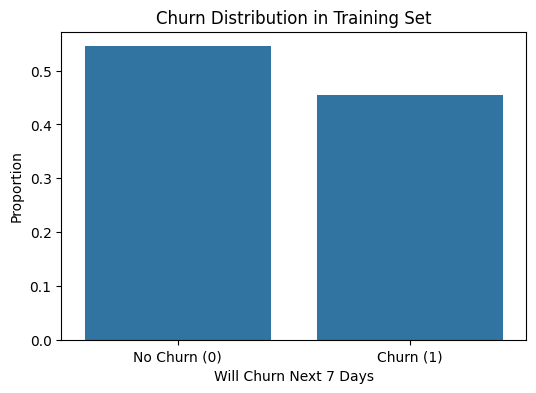

In [85]:
churn_distribution = y_train.value_counts(normalize=True)
print("Churn Distribution in Training Set:")
print(churn_distribution)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.barplot(x=churn_distribution.index, y=churn_distribution.values)
plt.title('Churn Distribution in Training Set')
plt.xlabel('Will Churn Next 7 Days')
plt.ylabel('Proportion')
plt.xticks(ticks=[0, 1], labels=['No Churn (0)', 'Churn (1)'])
plt.show()

### Feature Distributions (Histograms)

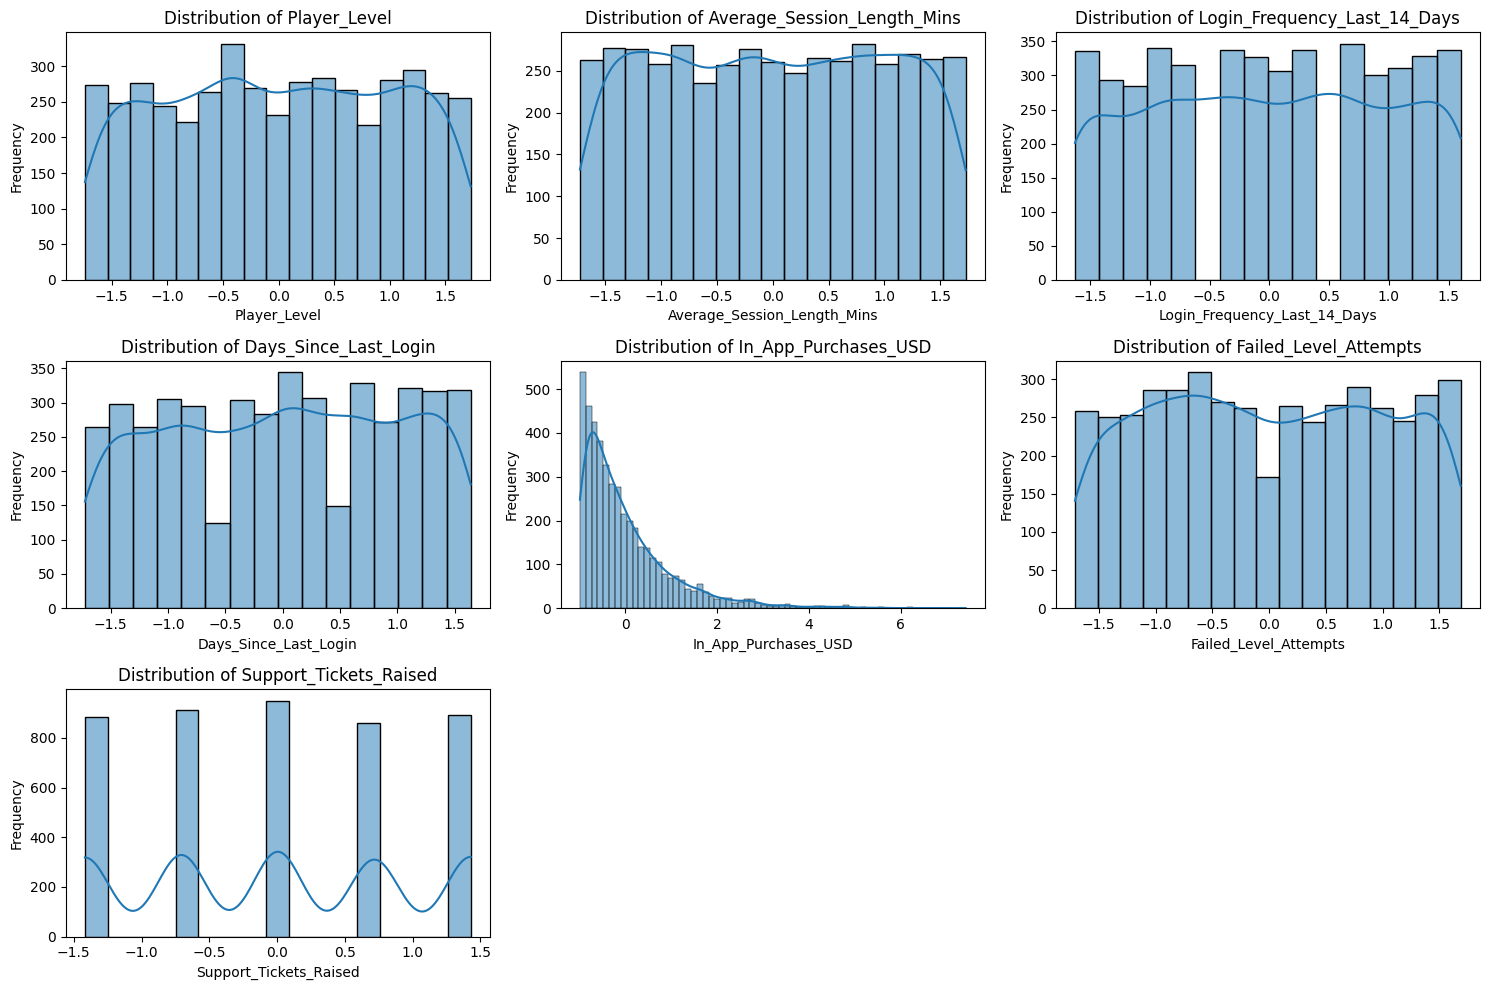

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

for i, col in enumerate(X_scaled_df.columns):
    plt.subplot(3, 3, i + 1)
    sns.histplot(X_scaled_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Feature Correlation Heatmap

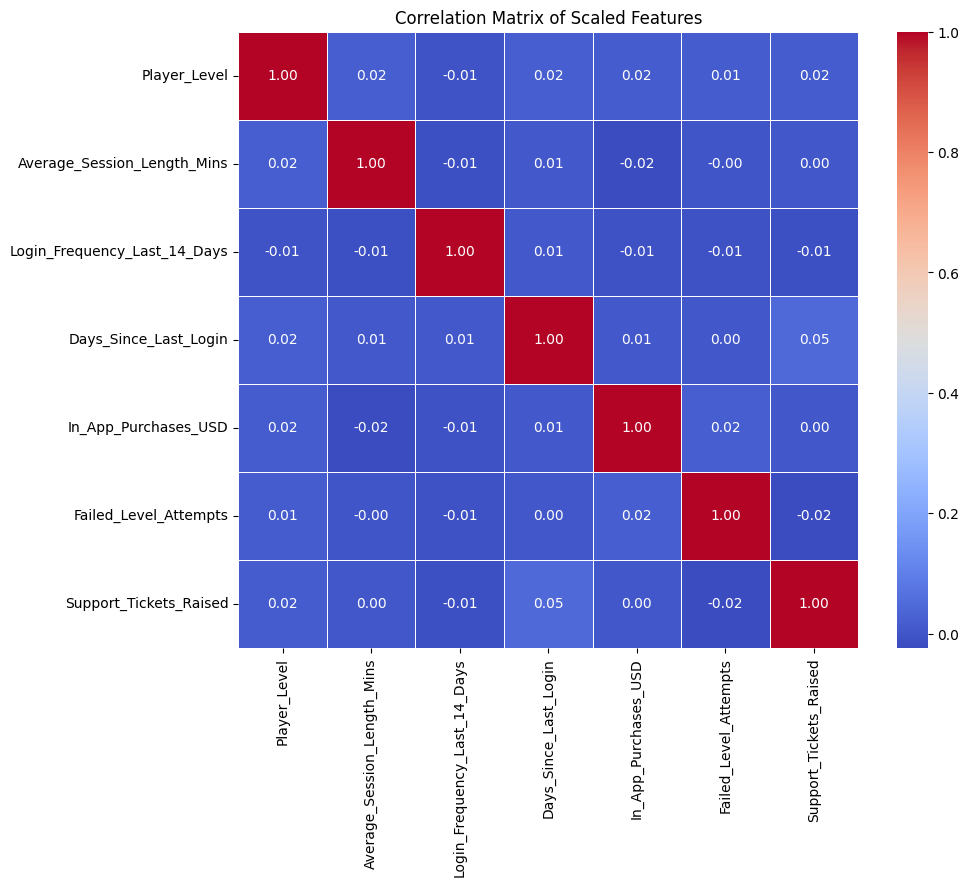

In [87]:
correlation_matrix = X_scaled_df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Scaled Features')
plt.show()

### Outlier Detection and Handling

In [88]:
import numpy as np

def detect_outliers_iqr(df_segment, column, q1=None, q3=None, iqr=None):
    if q1 is None or q3 is None or iqr is None:
        Q1_val = df_segment[column].quantile(0.25)
        Q3_val = df_segment[column].quantile(0.75)
        IQR_val = Q3_val - Q1_val
    else:
        Q1_val, Q3_val, IQR_val = q1, q3, iqr

    lower_bound = Q1_val - 1.5 * IQR_val
    upper_bound = Q3_val + 1.5 * IQR_val
    outliers = df_segment[(df_segment[column] < lower_bound) | (df_segment[column] > upper_bound)]
    return outliers.shape[0], Q1_val, Q3_val, IQR_val

outlier_bounds = {}

print("Number of outliers per feature (IQR method):")
print("  In X_train (bounds learned from X_train):")
for col in X_train.columns:
    count_train, Q1, Q3, IQR = detect_outliers_iqr(X_train, col)
    outlier_bounds[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR}
    print(f"    {col}: {count_train}")

print("  In X_test (using bounds learned from X_train):")
for col in X_test.columns:
    bounds = outlier_bounds[col]
    count_test, _, _, _ = detect_outliers_iqr(X_test, col, bounds['Q1'], bounds['Q3'], bounds['IQR'])
    print(f"    {col}: {count_test}")

Number of outliers per feature (IQR method):
  In X_train (bounds learned from X_train):
    Player_Level: 0
    Average_Session_Length_Mins: 0
    Login_Frequency_Last_14_Days: 0
    Days_Since_Last_Login: 0
    In_App_Purchases_USD: 182
    Failed_Level_Attempts: 0
    Support_Tickets_Raised: 0
  In X_test (using bounds learned from X_train):
    Player_Level: 0
    Average_Session_Length_Mins: 0
    Login_Frequency_Last_14_Days: 0
    Days_Since_Last_Login: 0
    In_App_Purchases_USD: 53
    Failed_Level_Attempts: 0
    Support_Tickets_Raised: 0


In [89]:
def cap_outliers_iqr_segment(df_segment, column, q1, q3, iqr):
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df_segment[column] = np.where(df_segment[column] < lower_bound, lower_bound, df_segment[column])
    df_segment[column] = np.where(df_segment[column] > upper_bound, upper_bound, df_segment[column])
    return df_segment

for col in X_train.columns:
    bounds = outlier_bounds[col]
    X_train = cap_outliers_iqr_segment(X_train.copy(), col, bounds['Q1'], bounds['Q3'], bounds['IQR'])

for col in X_test.columns:
    bounds = outlier_bounds[col]
    X_test = cap_outliers_iqr_segment(X_test.copy(), col, bounds['Q1'], bounds['Q3'], bounds['IQR'])

print("Outliers have been capped in X_train and X_test using training data bounds.")
display(X_train.head())
display(X_test.head())

Outliers have been capped in X_train and X_test using training data bounds.


,Player_Level,Average_Session_Length_Mins,Login_Frequency_Last_14_Days,Days_Since_Last_Login,In_App_Purchases_USD,Failed_Level_Attempts,Support_Tickets_Raised
26,-0.210743,1.536309,0.099753,0.474429,-0.597046,0.446999,-1.409555
319,0.715688,-1.406686,-0.396942,0.008732,0.398294,0.516628,1.428475
2630,-0.068215,0.171184,0.348100,0.008732,-0.182593,0.238112,-0.700047
644,1.713382,-1.357439,1.341489,1.172976,-0.930566,0.725514,-1.409555
3532,0.501896,0.179064,1.093142,0.125156,0.355870,-0.597436,0.009460


,Player_Level,Average_Session_Length_Mins,Login_Frequency_Last_14_Days,Days_Since_Last_Login,In_App_Purchases_USD,Failed_Level_Attempts,Support_Tickets_Raised
1526,1.357063,1.081267,0.348100,0.940127,-0.890100,-0.667065,0.009460
2468,0.715688,-1.331831,-0.893636,0.707278,-0.553969,1.352175,0.009460
4454,1.570855,1.142333,0.099753,0.125156,0.555591,1.561062,0.718967
3815,0.680056,1.719507,0.099753,1.172976,1.247434,0.377370,1.428475
2147,-0.994646,1.087177,-0.148594,-0.107693,-0.806557,1.212917,0.718967


### Model Training and Evaluation

In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, StratifiedKFold

import warnings
warnings.filterwarnings('ignore')

In [91]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear'),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier()
}

results = {}

In [92]:
for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else 'N/A'

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    }

    print(f"{name} Performance:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}" if roc_auc != 'N/A' else f"  ROC-AUC: {roc_auc}")
    print(f"  Classification Report:\n{classification_report(y_test, y_pred)}")


Training Logistic Regression...
Logistic Regression Performance:
  Accuracy: 0.6856
  Precision: 0.6632
  Recall: 0.6259
  F1 Score: 0.6440
  ROC-AUC: 0.7634
  Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.74      0.72       491
           1       0.66      0.63      0.64       409

    accuracy                           0.69       900
   macro avg       0.68      0.68      0.68       900
weighted avg       0.68      0.69      0.68       900


Training Decision Tree...
Decision Tree Performance:
  Accuracy: 0.6289
  Precision: 0.5908
  Recall: 0.5966
  F1 Score: 0.5937
  ROC-AUC: 0.6262
  Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.66      0.66       491
           1       0.59      0.60      0.59       409

    accuracy                           0.63       900
   macro avg       0.63      0.63      0.63       900
weighted avg       0.63      0.63      0.63  

In [93]:
print("\n--- Model Comparison ---")
performance_df = pd.DataFrame(results).T
display(performance_df.sort_values(by='F1 Score', ascending=False))


--- Model Comparison ---


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Gradient Boosting,0.724444,0.713528,0.657702,0.684478,0.788685
Logistic Regression,0.685556,0.663212,0.625917,0.644025,0.763354
Random Forest,0.680000,0.663957,0.599022,0.629820,0.765692
K-Nearest Neighbors,0.655556,0.627907,0.594132,0.610553,0.691040
Decision Tree,0.628889,0.590799,0.596577,0.593674,0.626191


### Cross-Validation for Robust Evaluation

In [94]:
cv_results = {}
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

for name, model in models.items():
    print(f"\nPerforming 5-fold cross-validation for {name}...")
    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = {}
    for metric in scoring:
        scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring=metric, n_jobs=-1)
        cv_scores[metric] = scores.mean()
        print(f"  Mean {metric.replace('_', ' ').title()}: {scores.mean():.4f} (+/- {scores.std():.4f})")
    cv_results[name] = cv_scores

cv_performance_df = pd.DataFrame(cv_results).T
print("\n--- Cross-Validation Model Comparison ---")
display(cv_performance_df.sort_values(by='f1', ascending=False))


Performing 5-fold cross-validation for Logistic Regression...
  Mean Accuracy: 0.6756 (+/- 0.0208)
  Mean Precision: 0.6578 (+/- 0.0220)
  Mean Recall: 0.5971 (+/- 0.0335)
  Mean F1: 0.6258 (+/- 0.0274)
  Mean Roc Auc: 0.7318 (+/- 0.0160)

Performing 5-fold cross-validation for Decision Tree...
  Mean Accuracy: 0.6161 (+/- 0.0192)
  Mean Precision: 0.5758 (+/- 0.0190)
  Mean Recall: 0.5910 (+/- 0.0327)
  Mean F1: 0.5832 (+/- 0.0255)
  Mean Roc Auc: 0.6140 (+/- 0.0202)

Performing 5-fold cross-validation for Random Forest...
  Mean Accuracy: 0.6819 (+/- 0.0154)
  Mean Precision: 0.6635 (+/- 0.0123)
  Mean Recall: 0.6099 (+/- 0.0344)
  Mean F1: 0.6353 (+/- 0.0235)
  Mean Roc Auc: 0.7464 (+/- 0.0124)

Performing 5-fold cross-validation for Gradient Boosting...
  Mean Accuracy: 0.6950 (+/- 0.0122)
  Mean Precision: 0.6779 (+/- 0.0053)
  Mean Recall: 0.6276 (+/- 0.0352)
  Mean F1: 0.6514 (+/- 0.0210)
  Mean Roc Auc: 0.7640 (+/- 0.0111)

Performing 5-fold cross-validation for K-Nearest Neig

,accuracy,precision,recall,f1,roc_auc
Gradient Boosting,0.695000,0.677858,0.627637,0.651413,0.763997
Random Forest,0.681944,0.663451,0.609926,0.635286,0.746371
Logistic Regression,0.675556,0.657844,0.597115,0.625846,0.731793
K-Nearest Neighbors,0.641389,0.608911,0.591586,0.599994,0.680043
Decision Tree,0.616111,0.575794,0.590992,0.583204,0.614046


### Hyperparameter Tuning

In [95]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import GradientBoostingClassifier

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 0.9]
}

grid_search_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_gb,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Performing Grid Search for Gradient Boosting...")
grid_search_gb.fit(X_train, y_train)

print("Best parameters for Gradient Boosting:", grid_search_gb.best_params_)
print("Best F1 Score for Gradient Boosting:", grid_search_gb.best_score_)

best_gb_model = grid_search_gb.best_estimator_

Performing Grid Search for Gradient Boosting...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}
Best F1 Score for Gradient Boosting: 0.6547926841803504


In [96]:
y_pred_gb = best_gb_model.predict(X_test)
y_pred_proba_gb = best_gb_model.predict_proba(X_test)[:, 1]

accuracy_gb = accuracy_score(y_test, y_pred_gb)
precision_gb = precision_score(y_test, y_pred_gb)
recall_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
roc_auc_gb = roc_auc_score(y_test, y_pred_proba_gb)

print("\n--- Tuned Gradient Boosting Model Performance on Test Set ---")
print(f"  Accuracy: {accuracy_gb:.4f}")
print(f"  Precision: {precision_gb:.4f}")
print(f"  Recall: {recall_gb:.4f}")
print(f"  F1 Score: {f1_gb:.4f}")
print(f"  ROC-AUC: {roc_auc_gb:.4f}")
print(f"  Classification Report:\n{classification_report(y_test, y_pred_gb)}")

results['Tuned Gradient Boosting'] = {
    'Accuracy': accuracy_gb,
    'Precision': precision_gb,
    'Recall': recall_gb,
    'F1 Score': f1_gb,
    'ROC-AUC': roc_auc_gb
}

performance_df = pd.DataFrame(results).T
print("\n--- Updated Model Comparison ---")
display(performance_df.sort_values(by='F1 Score', ascending=False))


--- Tuned Gradient Boosting Model Performance on Test Set ---
  Accuracy: 0.7033
  Precision: 0.6919
  Recall: 0.6259
  F1 Score: 0.6573
  ROC-AUC: 0.7846
  Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.77      0.74       491
           1       0.69      0.63      0.66       409

    accuracy                           0.70       900
   macro avg       0.70      0.70      0.70       900
weighted avg       0.70      0.70      0.70       900


--- Updated Model Comparison ---


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Gradient Boosting,0.724444,0.713528,0.657702,0.684478,0.788685
Tuned Gradient Boosting,0.703333,0.691892,0.625917,0.657253,0.784577
Logistic Regression,0.685556,0.663212,0.625917,0.644025,0.763354
Random Forest,0.680000,0.663957,0.599022,0.629820,0.765692
K-Nearest Neighbors,0.655556,0.627907,0.594132,0.610553,0.691040
Decision Tree,0.628889,0.590799,0.596577,0.593674,0.626191


### Prediction on New Dataset

In [97]:
import pandas as pd

try:
    new_df = pd.read_excel('/content/New_Gamer_Data..xlsx')
    print("New dataset loaded successfully:")
    display(new_df.head())
    print(f"Shape of new dataset: {new_df.shape}")
except FileNotFoundError:
    print("Error: 'New_Gamer_Data..xlsx' not found in /content/. Please upload the file or update the path.")
    new_df = None

New dataset loaded successfully:


,Player_ID,Player_Level,Average_Session_Length_Mins,Login_Frequency_Last_14_Days,Days_Since_Last_Login,In_App_Purchases_USD,Failed_Level_Attempts,Support_Tickets_Raised
0,200000,2,169.6,4,10,9.97,6,0
1,200001,36,110.2,3,17,63.35,41,3
2,200002,58,54.7,12,29,0.22,3,1
3,200003,41,36.9,11,14,5.60,29,2
4,200004,74,27.3,4,10,0.02,11,0


Shape of new dataset: (500, 8)


In [98]:
if new_df is not None:
    new_player_ids = new_df['Player_ID']

    new_df_processed = new_df.drop('Player_ID', axis=1)

    new_X_features = new_df_processed[numerical_cols]

    new_X_scaled = scaler.transform(new_X_features)
    new_X_scaled_df = pd.DataFrame(new_X_scaled, columns=numerical_cols, index=new_X_features.index)

    for col in new_X_scaled_df.columns:
        if col in outlier_bounds:
            bounds = outlier_bounds[col]
            new_X_scaled_df = cap_outliers_iqr_segment(new_X_scaled_df.copy(), col, bounds['Q1'], bounds['Q3'], bounds['IQR'])

    print("New dataset preprocessed successfully. Head of scaled and capped features:")
    display(new_X_scaled_df.head())
else:
    print("Skipping preprocessing as new_df was not loaded.")
    new_X_scaled_df = None

New dataset preprocessed successfully. Head of scaled and capped features:


,Player_Level,Average_Session_Length_Mins,Login_Frequency_Last_14_Days,Days_Since_Last_Login,In_App_Purchases_USD,Failed_Level_Attempts,Support_Tickets_Raised
0,-1.706203,1.523595,-0.882699,-0.564984,-0.335397,-1.293403,-1.417592
1,-0.502530,0.351013,-1.131036,0.247738,1.912925,1.132854,0.717812
2,0.276318,-0.744581,1.103995,1.640976,-0.975198,-1.501368,-0.705790
3,-0.325519,-1.095960,0.855658,-0.100571,-0.622159,0.300995,0.006011
4,0.842752,-1.285468,-0.882699,-0.564984,-0.988322,-0.946795,-1.417592


In [99]:
if new_X_scaled_df is not None and new_player_ids is not None:
    new_predictions = best_gb_model.predict(new_X_scaled_df)
    new_prediction_proba = best_gb_model.predict_proba(new_X_scaled_df)[:, 1]

    predictions_df = pd.DataFrame({
        'Player_ID': new_player_ids,
        'Predicted_Churn': new_predictions,
        'Churn_Probability': new_prediction_proba
    })

    print("Predictions for the new dataset:")
    display(predictions_df.head(10))

    print("\nPredicted Churn Distribution for New Players:")
    display(predictions_df['Predicted_Churn'].value_counts())
else:
    print("Skipping predictions as new_X_scaled_df or new_player_ids were not created during preprocessing.")

Predictions for the new dataset:


,Player_ID,Predicted_Churn,Churn_Probability
0,200000,0,0.198118
1,200001,1,0.872308
2,200002,0,0.182830
3,200003,0,0.335976
4,200004,0,0.039327
5,200005,1,0.592774
6,200006,0,0.284972
7,200007,0,0.213702
8,200008,1,0.807445
9,200009,1,0.549987



Predicted Churn Distribution for New Players:


,count
Predicted_Churn,
0,308
1,192


In [100]:
import joblib


joblib.dump(best_gb_model, 'best_gb_model.pkl')
print("Trained Gradient Boosting model saved as 'best_gb_model.pkl'")


joblib.dump(scaler, 'scaler.pkl')
print("StandardScaler saved as 'scaler.pkl'")


joblib.dump(outlier_bounds, 'outlier_bounds.pkl')
print("Outlier bounds saved as 'outlier_bounds.pkl'")

Trained Gradient Boosting model saved as 'best_gb_model.pkl'
StandardScaler saved as 'scaler.pkl'
Outlier bounds saved as 'outlier_bounds.pkl'


In [101]:
import os

app_py_content = """
from flask import Flask, request, jsonify, render_template
import joblib
import pandas as pd
import numpy as np

app = Flask(__name__)

model = joblib.load('best_gb_model.pkl')
scaler = joblib.load('scaler.pkl')
outlier_bounds = joblib.load('outlier_bounds.pkl')

def cap_outliers_iqr_segment(df_segment, column, q1, q3, iqr):
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df_segment[column] = np.where(df_segment[column] < lower_bound, lower_bound, df_segment[column])
    df_segment[column] = np.where(df_segment[column] > upper_bound, upper_bound, df_segment[column])
    return df_segment

@app.route('/')
def home():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.form.to_dict()
        player_data = {
            'Player_Level': float(data.get('player_level')),
            'Average_Session_Length_Mins': float(data.get('average_session_length_mins')),
            'Login_Frequency_Last_14_Days': float(data.get('login_frequency_last_14_days')),
            'Days_Since_Last_Login': float(data.get('days_since_last_login')),
            'In_App_Purchases_USD': float(data.get('in_app_purchases_usd')),
            'Failed_Level_Attempts': float(data.get('failed_level_attempts')),
            'Support_Tickets_Raised': float(data.get('support_tickets_raised'))
        }

        player_df = pd.DataFrame([player_data])

        scaled_player_data = scaler.transform(player_df)
        scaled_player_df = pd.DataFrame(scaled_player_data, columns=player_df.columns)

        for col in scaled_player_df.columns:
            if col in outlier_bounds:
                bounds = outlier_bounds[col]
                scaled_player_df = cap_outliers_iqr_segment(scaled_player_df, col, bounds['Q1'], bounds['Q3'], bounds['IQR'])

        prediction = model.predict(scaled_player_df)[0]
        prediction_proba = model.predict_proba(scaled_player_df)[0][1]

        return jsonify({
            'prediction': int(prediction),
            'probability': float(prediction_proba),
            'message': 'Player is likely to churn' if prediction == 1 else 'Player is likely to not churn'
        })
    except Exception as e:
        return jsonify({'error': str(e)}), 400

if __name__ == '__main__':
    app.run(debug=True, port=5000)
"""

index_html_content = """
<!doctype html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Gamer Churn Prediction</title>
    <style>
        body { font-family: Arial, sans-serif; margin: 20px; background-color: #f4f4f4; }
        .container { background-color: #fff; padding: 30px; border-radius: 8px; box-shadow: 0 2px 4px rgba(0,0,0,0.1); max-width: 600px; margin: auto; }
        h1 { color: #333; text-align: center; margin-bottom: 30px; }
        .form-group { margin-bottom: 15px; }
        label { display: block; margin-bottom: 5px; color: #555; font-weight: bold; }
        input[type="number"] { width: calc(100% - 22px); padding: 10px; border: 1px solid #ddd; border-radius: 4px; }
        button { background-color: #007bff; color: white; padding: 12px 20px; border: none; border-radius: 4px; cursor: pointer; width: 100%; font-size: 16px; margin-top: 20px; }
        button:hover { background-color: #0056b3; }
        #predictionResult { margin-top: 30px; padding: 15px; border-radius: 5px; border: 1px solid #ccc; background-color: #e9ecef; text-align: center; }
        #predictionResult p { margin: 5px 0; font-size: 1.1em; color: #333; }
        .churn { color: #dc3545; font-weight: bold; }
        .no-churn { color: #28a745; font-weight: bold; }
    </style>
</head>
<body>
    <div class="container">
        <h1>Gamer Churn Prediction</h1>
        <form id="predictionForm">
            <div class="form-group">
                <label for="player_level">Player Level:</label>
                <input type="number" id="player_level" name="player_level" value="50" required>
            </div>
            <div class="form-group">
                <label for="average_session_length_mins">Average Session Length (Mins):</label>
                <input type="number" id="average_session_length_mins" name="average_session_length_mins" step="0.1" value="60.5" required>
            </div>
            <div class="form-group">
                <label for="login_frequency_last_14_days">Login Frequency (Last 14 Days):</label>
                <input type="number" id="login_frequency_last_14_days" name="login_frequency_last_14_days" value="7" required>
            </div>
            <div class="form-group">
                <label for="days_since_last_login">Days Since Last Login:</label>
                <input type="number" id="days_since_last_login" name="days_since_last_login" value="3" required>
            </div>
            <div class="form-group">
                <label for="in_app_purchases_usd">In-App Purchases (USD):</label>
                <input type="number" id="in_app_purchases_usd" name="in_app_purchases_usd" step="0.01" value="25.00" required>
            </div>
            <div class="form-group">
                <label for="failed_level_attempts">Failed Level Attempts:</label>
                <input type="number" id="failed_level_attempts" name="failed_level_attempts" value="10" required>
            </div>
            <div class="form-group">
                <label for="support_tickets_raised">Support Tickets Raised:</label>
                <input type="number" id="support_tickets_raised" name="support_tickets_raised" value="1" required>
            </div>
            <button type="submit">Get Churn Prediction</button>
        </form>

        <div id="predictionResult" style="display:none;">
            <p><strong>Prediction:</strong> <span id="predictionText"></span></p>
            <p><strong>Churn Probability:</strong> <span id="probabilityText"></span></p>
        </div>
    </div>

    <script>
        document.getElementById('predictionForm').addEventListener('submit', async function(event) {
            event.preventDefault();
            const formData = new FormData(this);
            const response = await fetch('/predict', {
                method: 'POST',
                body: formData
            });
            const result = await response.json();

            const predictionResultDiv = document.getElementById('predictionResult');
            const predictionTextSpan = document.getElementById('predictionText');
            const probabilityTextSpan = document.getElementById('probabilityText');

            if (result.error) {
                predictionTextSpan.textContent = `Error: ${result.error}`;
                probabilityTextSpan.textContent = '';
                predictionTextSpan.className = 'churn';
            } else {
                predictionTextSpan.textContent = result.message;
                probabilityTextSpan.textContent = `${(result.probability * 100).toFixed(2)}%`;

                if (result.prediction === 1) {
                    predictionTextSpan.className = 'churn';
                } else {
                    predictionTextSpan.className = 'no-churn';
                }
            }
            predictionResultDiv.style.display = 'block';
        });
    </script>
</body>
</html>
"""


if not os.path.exists('templates'):
    os.makedirs('templates')


with open('app.py', 'w') as f:
    f.write(app_py_content)
print("app.py created.")


with open('templates/index.html', 'w') as f:
    f.write(index_html_content)
print("templates/index.html created.")

app.py created.
templates/index.html created.
